# 01 - Exploratory Data Analysis

Dataset: Kaggle "Brain Tumor MRI Dataset" v2 (4 classes: glioma, meningioma, pituitary, notumor).

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from tqdm.auto import tqdm

c:\Users\briek\Desktop\AI_Portfolio\brain-tumor-mri-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Paths

In [ ]:
DATA_DIR = Path("..") / "data"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"

## 3. Class distribution

### 3.1 Image table

One row per image. Split and label come from the folder names: `data/<split>/<label>/<file>.jpg`.

In [3]:
paths = sorted(DATA_DIR.glob("*/*/*.jpg"))

df = pd.DataFrame({"path": paths})
df["split"] = [p.parent.parent.name for p in paths]
df["label"] = [p.parent.name for p in paths]
df.head()

,path,split,label
0,..\data\Testing\glioma\Te-gl_1.jpg,Testing,glioma
1,..\data\Testing\glioma\Te-gl_10.jpg,Testing,glioma
2,..\data\Testing\glioma\Te-gl_100.jpg,Testing,glioma
3,..\data\Testing\glioma\Te-gl_101.jpg,Testing,glioma
4,..\data\Testing\glioma\Te-gl_102.jpg,Testing,glioma


### 3.2 Counts per class and split

In [ ]:
counts = pd.crosstab(df["label"], df["split"], margins=True, margins_name="total")
counts

split,Testing,Training,total
label,,,
glioma,400,1400,1800
meningioma,400,1400,1800
notumor,400,1400,1800
pituitary,400,1400,1800
total,1600,5600,7200


### 3.3 Plot

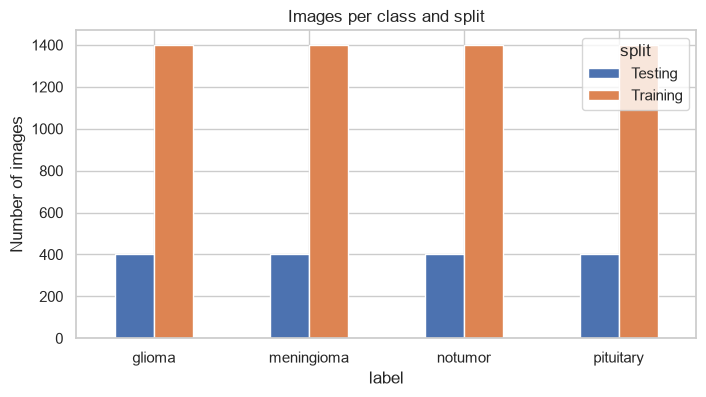

In [5]:
counts.drop(index="total", columns="total").plot(kind="bar", rot=0, figsize=(8, 4), title="Images per class and split")
plt.ylabel("Number of images")
plt.show()

### 3.4 Conclusions

- 7,200 images: 1,400 train and 400 test per class, so the classes are perfectly balanced.
- No validation set yet: it will be split off from the training data in `02_preprocessing`.